In [1]:
import numpy as np
import scipy
import sys
sys.path.append('/Users/stylianoskampakis/Dropbox (Personal)/Freelance/TokenLab/build/lib/TokenLab')

from simulationcomponents import *
from simulationcomponents.usergrowthclasses import *
from simulationcomponents.transactionclasses import *
from simulationcomponents.tokeneconomyclasses import *
from simulationcomponents.transactionclasses import *
from simulationcomponents.agentpoolclasses import *
from simulationcomponents.pricingclasses import *
from utils.helpers import *
from matplotlib import pyplot as plt

# Globals

In [2]:
ITERATIONS=72
HOLDING_TIME=0.1
SUPPLY=0.17*10**9

## Luxury digital art fractional marketplace

In [3]:
#Primary
usm_luxury=UserGrowth_Spaced(10,54,ITERATIONS,log_saturated_space)
tsm_luxury=TransactionManagement_Stochastic(activity_probs=np.linspace(0.25,0.1,ITERATIONS),
                                            value_dist_parameters={'loc':10000,'scale':10000/7},
                                           transactions_dist_parameters={'mu':1})

ap_luxury=AgentPool_Basic(users_controller=usm_luxury,transactions_controller=tsm_luxury,currency='$')

In [4]:
#Secondary
#make the sequence of parameters
loc_param=generate_distribution_param_from_sequence('loc',np.linspace,500,750,ITERATIONS)
scale_param=generate_distribution_param_from_sequence('scale',np.linspace,500/7,750/7,ITERATIONS)
value_dist_params=merge_param_dists(loc_param,scale_param)


usm_luxury_sec=UserGrowth_Spaced(10000,327800 ,ITERATIONS,log_saturated_space)
tsm_luxury_sec=TransactionManagement_Stochastic(activity_probs=np.linspace(0.25,0.1,ITERATIONS),
                                            value_dist_parameters=value_dist_params,
                                           transactions_dist_parameters={'mu':26/12})

ap_luxury_sec=AgentPool_Basic(users_controller=usm_luxury_sec,transactions_controller=tsm_luxury_sec,currency='$')

## Fine physical art marketplace

In [5]:
#Primary
loc_param=generate_distribution_param_from_sequence('loc',np.linspace,200000,500000,ITERATIONS)
scale_param=generate_distribution_param_from_sequence('scale',np.linspace,200000/7,500000/7,ITERATIONS)
value_dist_params=merge_param_dists(loc_param,scale_param)

usm_fine=UserGrowth_Spaced(5,27,ITERATIONS,log_saturated_space)
tsm_fine=TransactionManagement_Stochastic(activity_probs=np.linspace(0.75,0.25,ITERATIONS),
                                          value_dist_parameters=value_dist_params,
                                           transactions_dist_parameters={'mu':1})

ap_fine=AgentPool_Basic(users_controller=usm_fine,transactions_controller=tsm_fine,currency='$')

In [6]:
#Secondary
loc_param=generate_distribution_param_from_sequence('loc',np.linspace,500,1000,ITERATIONS)
scale_param=generate_distribution_param_from_sequence('scale',np.linspace,500/7,1000/7,ITERATIONS)
value_dist_params=merge_param_dists(loc_param,scale_param)

usm_fine_sec=UserGrowth_Spaced(10000,327800,ITERATIONS,log_saturated_space)
tsm_fine_sec=TransactionManagement_Stochastic(activity_probs=np.linspace(0.25,0.10,ITERATIONS),
                                          value_dist_parameters=value_dist_params,
                                           transactions_dist_parameters={'mu':26/12})

ap_fine_sec=AgentPool_Basic(users_controller=usm_fine_sec,transactions_controller=tsm_fine_sec,currency='$')

## Own fine art


In [7]:
#Primary
tsm_own=TransactionManagement_Stochastic(value_per_transaction=10000,
                                           transactions_dist_parameters={'mu':52/12})

                                          
ap_own=AgentPool_Basic(users_controller=1,transactions_controller=tsm_own,currency='$')

# Token economy

In [8]:
te=TokenEconomy_Basic(holding_time=HOLDING_TIME,supply=SUPPLY,initial_price=1)
te.add_agent_pools([ap_luxury,ap_luxury_sec,ap_fine,ap_fine_sec,ap_own])

True

In [9]:
meta=TokenMetaSimulator(te)
meta.execute(iterations=ITERATIONS,repetitions=50)
reps=meta.get_data()

100%|███████████████████████████████████████████| 50/50 [00:09<00:00,  5.48it/s]


In [10]:
reps

,token_price,transactions_$,num_users,iteration,holding_time,effective_holding_time,supply,transactions_token,repetition_run,iteration_time
0,0.055771,9.480995e+07,490008,1,0.1,0.1,170000000.0,4000.000000,0,0
1,0.096667,1.643342e+08,999695,2,0.1,0.1,170000000.0,107583.642491,0,1
2,0.098454,1.673711e+08,1523716,3,0.1,0.1,170000000.0,62068.628433,0,2
3,0.061281,1.041774e+08,2059018,4,0.1,0.1,170000000.0,40628.275797,0,3
4,0.103723,1.763299e+08,2603621,5,0.1,0.1,170000000.0,114228.198928,0,4
...,...,...,...,...,...,...,...,...,...,...
67,0.055706,9.469974e+07,42493758,68,0.1,0.1,170000000.0,78713.705379,49,67
68,0.076200,1.295403e+08,43167228,69,0.1,0.1,170000000.0,107708.851401,49,68
69,0.131324,2.232513e+08,43841453,70,0.1,0.1,170000000.0,52493.335117,49,69
70,0.167048,2.839808e+08,44516418,71,0.1,0.1,170000000.0,22844.212381,49,70


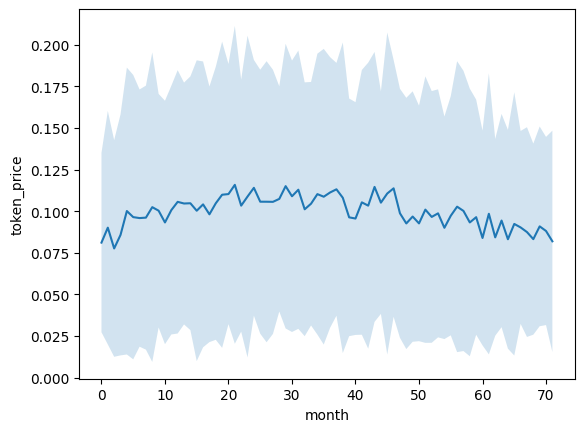

In [11]:
plot,data=meta.get_timeseries('token_price')
plot

# Stochastic holding time

In [12]:
te=TokenEconomy_Basic(holding_time=HoldingTime_Stochastic(),supply=SUPPLY,initial_price=1)
te.add_agent_pools([ap_luxury,ap_luxury_sec,ap_fine,ap_fine_sec,ap_own])
meta=TokenMetaSimulator(te)
meta.execute(iterations=ITERATIONS,repetitions=50)
reps=meta.get_data()
plot,data=meta.get_timeseries('price')
plot

100%|███████████████████████████████████████████| 50/50 [00:09<00:00,  5.29it/s]


KeyError: 'Column not found: price'

# Price plus noise

In [ ]:
te=TokenEconomy_Basic(holding_time=HoldingTime_Stochastic(),supply=SUPPLY,price_function=PriceFunction_EOE_Noise)
te.add_agent_pools([ap_luxury,ap_luxury_sec,ap_fine,ap_fine_sec,ap_own])
meta=TokenMetaSimulator(te)
meta.execute(iterations=ITERATIONS,repetitions=50)
reps=meta.get_data()
plot,data=meta.get_timeseries('price')
plot

# Price plus noise plus adaptive variance

In [ ]:
te=TokenEconomy_Basic(holding_time=HoldingTime_Stochastic(),supply=SUPPLY,price_function=PriceFunction_EOE_AdaptiveNoise)
te.add_agent_pools([ap_luxury,ap_luxury_sec,ap_fine,ap_fine_sec,ap_own])
meta=TokenMetaSimulator(te)
meta.execute(iterations=ITERATIONS,repetitions=50)
reps=meta.get_data()
plot,data=meta.get_timeseries('price')
plot